# Day 3 — Logistic Regression & Classification Metrics
## Logistic Regression for Titanic Survival Prediction

In this notebook, we build a Logistic Regression classifier to predict passenger survival on the Titanic dataset.

The workflow includes:
- Training a Logistic Regression model
- Making predictions
- Evaluating the model using classification metrics
- Computing the ROC-AUC score

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)
import matplotlib.pyplot as plt

## Step 1: Load the Dataset

The Titanic dataset is loaded using pandas.

This dataset contains information about passengers, including demographic details, ticket information, and survival status.

The goal is to use passenger features to predict whether a passenger survived or not.

In [49]:
df = pd.read_csv("Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Step 2: Data Cleaning and Feature Selection

Before training the Logistic Regression model, the dataset is prepared by selecting the relevant features and handling missing values.

### Selecting Relevant Features

The dataset contains several columns that are not useful for prediction, such as passenger identifiers, names, ticket information, and cabin details.

Only the important features that may influence survival prediction are selected:
- Passenger class (`Pclass`)
- Gender (`Sex`)
- Age (`Age`)
- Family relationships (`SibSp`, `Parch`)
- Ticket fare (`Fare`)
- Embarkation location (`Embarked`)

The remaining unnecessary columns are removed to keep only meaningful features for the model.

---

### Checking and Handling Missing Values

Before handling missing data, the dataset is checked for missing values to identify columns that require preprocessing.

Missing values are handled as follows:
- Missing values in the `Age` column are replaced using the median age value.
- Missing values in the `Embarked` column are replaced using the most frequent category.

After applying these changes, the dataset is checked again to ensure that no missing values remain.

---

### Encoding Categorical Features

Since Logistic Regression requires numerical input, categorical variables are converted into numerical representations.

The `Sex` column is encoded as:
- Male = 0
- Female = 1

The `Embarked` column is encoded as:
- S = 0
- C = 1
- Q = 2

After preprocessing, all selected features are in a numerical format suitable for training the model.

In [50]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [30]:
df = df[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked", "Survived"]]

df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode().iloc[0])

df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df["Embarked"] = df["Embarked"].map({"S": 0, "C": 1, "Q": 2})

### Verifying Missing Values After Preprocessing

After handling the missing values, the dataset is checked again using `isnull().sum()` to confirm that all missing values have been successfully handled.


In [35]:
df.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
Survived    0
dtype: int64

## Step 4: Separate Features and Target

The dataset is divided into:

- **Features (X):** The input variables used by the model to make predictions.
- **Target (y):** The output variable that represents passenger survival.

The `Survived` column is separated as the target, while all remaining columns are used as features.

In [31]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

## Step 5: Split the Dataset

The dataset is divided into training and testing sets using an 80/20 split.

The training data is used to train the Logistic Regression model, while the testing data is used to evaluate the model's ability to generalize to unseen data.

A fixed `random_state` is used to ensure reproducible results.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(712, 7)
(179, 7)


## Step 6: Train the Logistic Regression Model

A Logistic Regression classifier is created and trained using the training dataset.

Logistic Regression is a classification algorithm that estimates the probability of belonging to a specific class.

The trained model will be used to predict whether passengers survived or not.

In [34]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

## Step 7: Generate Predictions

The trained Logistic Regression model is used to predict survival outcomes for the test dataset.

Two types of outputs are generated:

- Class predictions using `predict()`.
- Class probabilities using `predict_proba()`.

The predicted probabilities are later used to calculate the ROC-AUC score.

In [39]:
predictions = model.predict(X_test)

probabilities = model.predict_proba(X_test)

print(predictions[:10])
print(probabilities[:5])

[0 0 0 1 1 1 1 0 1 1]
[[0.90583044 0.09416956]
 [0.77409921 0.22590079]
 [0.8646656  0.1353344 ]
 [0.10986329 0.89013671]
 [0.30094343 0.69905657]]


## Step 8: Confusion Matrix Evaluation

A confusion matrix is generated to evaluate the classification results.

It compares the actual survival labels with the predicted labels and shows:

- True Negatives: Correctly predicted non-survivors.
- False Positives: Non-survivors incorrectly predicted as survivors.
- False Negatives: Survivors incorrectly predicted as non-survivors.
- True Positives: Correctly predicted survivors.

This helps understand the types of errors made by the model.

In [40]:
cm = confusion_matrix(y_test, predictions)

print(cm)

[[89 16]
 [20 54]]


## Step 9: Classification Report

The classification report is used to evaluate the model using:

- **Precision:** Measures how many predicted survivors were actually survivors.
- **Recall:** Measures how many actual survivors were correctly identified.
- **F1-score:** Represents the balance between precision and recall.

These metrics provide a deeper evaluation of model performance compared to accuracy alone.

In [44]:
print("Classification Report\n" , classification_report(y_test, predictions))

Classification Report
               precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



### Metric Interpretation

For the survival class:

- Precision = 0.77, meaning that 77% of passengers predicted as survivors were actually survivors.
- Recall = 0.73, meaning that the model identified 73% of all actual survivors.
- F1-score = 0.75, showing a balanced performance between precision and recall.

### Precision vs Recall Decision

For Titanic survival prediction, recall is more important than precision.

The reason is that reducing False Negatives is more important in this scenario. A False Negative means that a passenger who actually survived was incorrectly predicted as not surviving.

Therefore, improving recall helps identify more actual survivors, even if this results in some additional False Positives.

## Step 10: Compute AUC-ROC Score

The ROC-AUC score is calculated to measure how well the model separates the two classes.

AUC represents the probability that the model ranks a randomly selected survivor higher than a randomly selected non-survivor.

The closer the value is to 1, the better the model distinguishes between classes.

In [42]:
auc = roc_auc_score(y_test, probabilities[:, 1])

print("AUC-ROC Score:", auc)

AUC-ROC Score: 0.8806949806949808


### AUC-ROC Interpretation

The model achieved an AUC-ROC score of approximately 0.88.

This indicates that the Logistic Regression model has a good ability to distinguish between survivors and non-survivors.

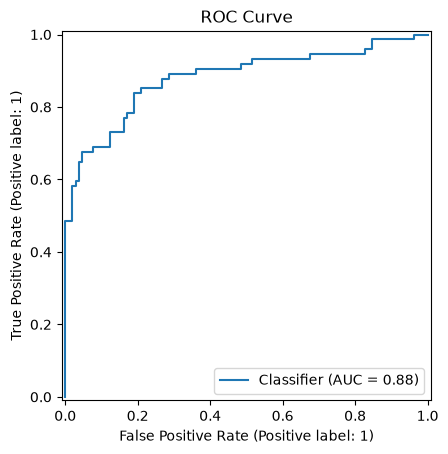

In [47]:
RocCurveDisplay.from_predictions(y_test, probabilities[:, 1])
plt.title("ROC Curve")
plt.show()

### ROC Curve Interpretation

The ROC (Receiver Operating Characteristic) curve illustrates the trade-off between the **True Positive Rate (Recall)** and the **False Positive Rate** across different classification thresholds.

The model achieved an **AUC-ROC score of 0.88**, indicating a strong ability to distinguish between the two classes. Since the curve stays well above the diagonal reference line and approaches the top-left corner, the classifier demonstrates good overall performance.

**Interpretation of the AUC value:**
- **AUC = 1.0** → Perfect classifier.
- **AUC ≥ 0.90** → Excellent performance.
- **AUC = 0.88** → Good performance.
- **AUC = 0.50** → No better than random guessing.

Overall, the Logistic Regression model performs well and can effectively differentiate between the positive and negative classes.